In [15]:
# =============================================================================
# NOTEBOOK 03: STAGE 2 — MODEL COMPARISON
# =============================================================================
# Compares ResNet50, EfficientNet-B0, MobileNetV2 using BOTH augmentation
# strategies from Stage 1 (Traditional Aug + MixUp/CutMix).
#
# ResNet50 results are reused from Stage 1 (Exp 1 and Exp 2).
# Only EfficientNet-B0 and MobileNetV2 are trained here (4 new experiments).
# =============================================================================

In [2]:
from utils import *
 
print("Classes:", CLASS_NAMES)
print("GPU:", tf.config.list_physical_devices('GPU'))

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
GPU: []


In [3]:
class_weights = compute_class_weights()
 
raw_train = load_base_dataset(TRAIN_DIR, shuffle=True)
raw_val   = load_base_dataset(VAL_DIR, shuffle=False)
raw_test  = load_base_dataset(TEST_DIR, shuffle=False)
 
val_ds  = build_dataset_no_aug(raw_val, shuffle=False)
test_ds = build_dataset_no_aug(raw_test, shuffle=False)
 
# Build both training datasets
train_ds_basic    = build_dataset_traditional_aug(raw_train)
train_ds_advanced = build_dataset_mixup_cutmix(raw_train)
 
print("All datasets ready.")

Found 8012 files belonging to 7 classes.
Found 1001 files belonging to 7 classes.
Found 1002 files belonging to 7 classes.
All datasets ready.


In [4]:
# Instead of re-training ResNet50, use the saved results from Stage 1.
 
resnet_basic_path = os.path.join(RESULTS_DIR, "exp1_resnet50_basic_aug_summary.json")
resnet_mixup_path = os.path.join(RESULTS_DIR, "exp2_resnet50_mixup_cutmix_summary.json")
 
with open(resnet_basic_path, 'r') as f:
    summary_resnet_basic = json.load(f)
print(f"Loaded: {summary_resnet_basic['experiment']}")
print(f"  Macro F1: {summary_resnet_basic['macro_f1']:.4f}, "
      f"Mel Recall: {summary_resnet_basic['mel_recall']:.4f}")
 
with open(resnet_mixup_path, 'r') as f:
    summary_resnet_mixup = json.load(f)
print(f"Loaded: {summary_resnet_mixup['experiment']}")
print(f"  Macro F1: {summary_resnet_mixup['macro_f1']:.4f}, "
      f"Mel Recall: {summary_resnet_mixup['mel_recall']:.4f}")
 

Loaded: exp1_resnet50_basic_aug
  Macro F1: 0.6887, Mel Recall: 0.8018
Loaded: exp2_resnet50_mixup_cutmix
  Macro F1: 0.6937, Mel Recall: 0.4775



############################################################
  EXPERIMENT: exp4a_efficientnetb0_basic_aug
############################################################



wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/emiryscn/.netrc.
wandb: Currently logged in as: emiryscn (emiryscn-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNet-B0 built. Base layers: 238, Total params: 4,379,306

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 236ms/step - accuracy: 0.4201 - loss: 1.5678 - val_accuracy: 0.4975 - val_loss: 1.2377 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 60s 234ms/step - accuracy: 0.5225 - loss: 1.2496 - val_accuracy: 0.6064 - val_loss: 1.0033 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 230ms/step - accuracy: 0.5482 - loss: 1.1743 - val_accuracy: 0.6014 - val_loss: 1.0449 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 60s 235ms/step - accuracy: 0.5520 - loss: 1.1016 - val_accuracy: 0.6214 - val_loss: 0.9381 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 231ms/step - accuracy: 0.5769 - loss: 1.0257 - val_accuracy: 0.6184 - val_loss: 0.9525 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 231ms/step - a

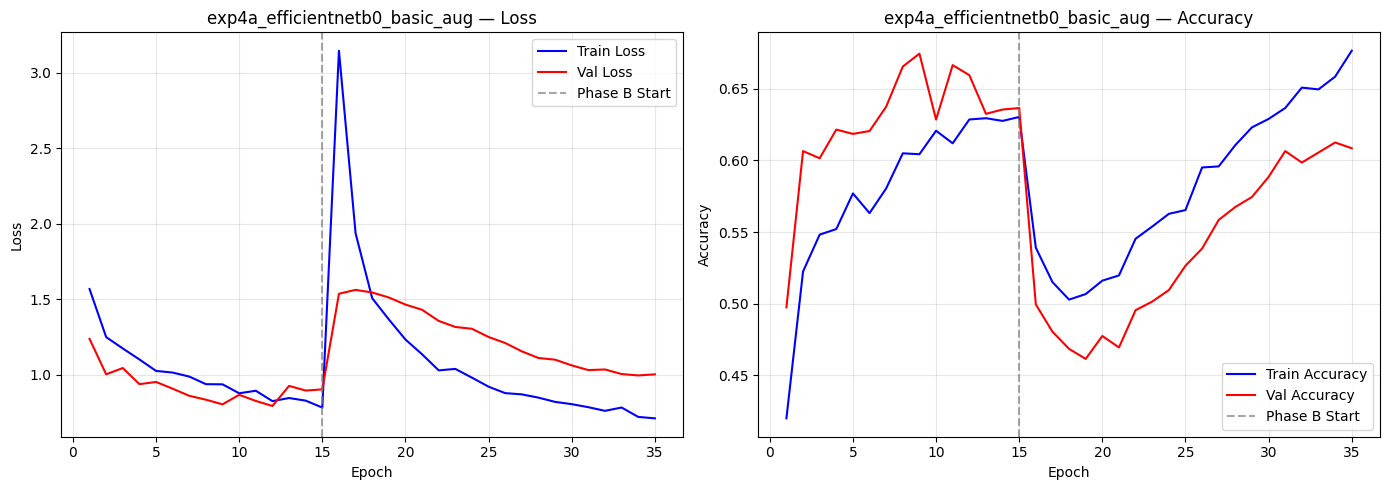


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp4a_efficientnetb0_basic_aug_final.keras

  EVALUATION: exp4a_efficientnetb0_basic_aug

              precision    recall  f1-score   support

       akiec     0.5556    0.4545    0.5000        33
         bcc     0.6304    0.5686    0.5979        51
         bkl     0.3208    0.7727    0.4533       110
          df     0.1944    0.5833    0.2917        12
         mel     0.3202    0.5135    0.3945       111
          nv     0.9602    0.6110    0.7468       671
        vasc     0.4783    0.7857    0.5946        14

    accuracy                         0.6128      1002
   macro avg     0.4943    0.6128    0.5113      1002
weighted avg     0.7731    0.6128    0.6523      1002



2026-03-13 21:48:35.902393: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


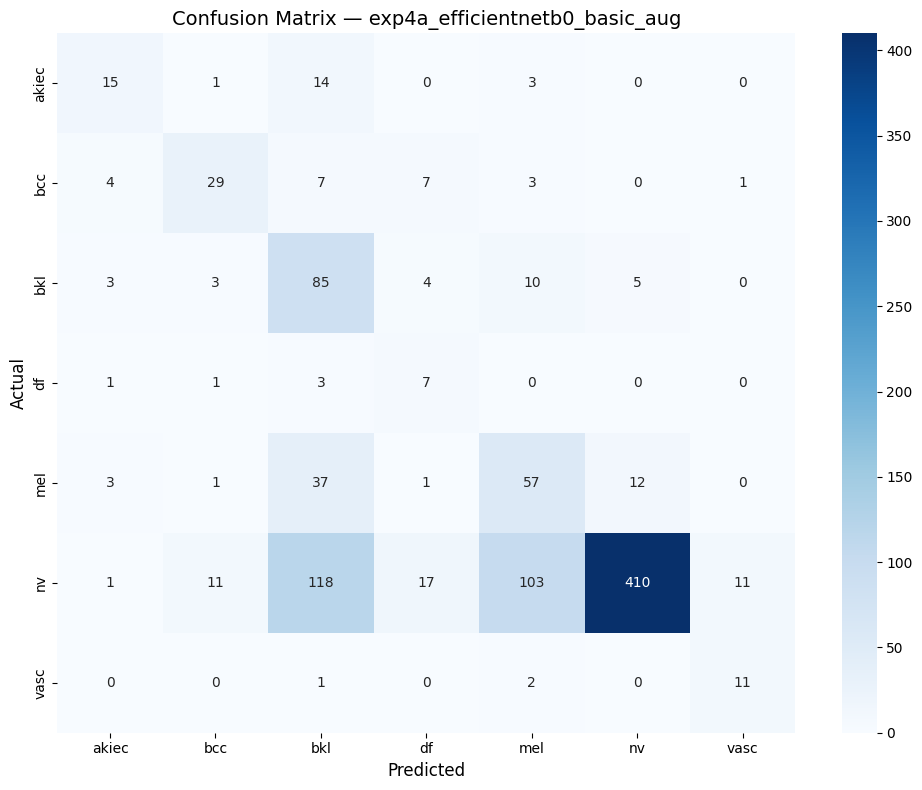

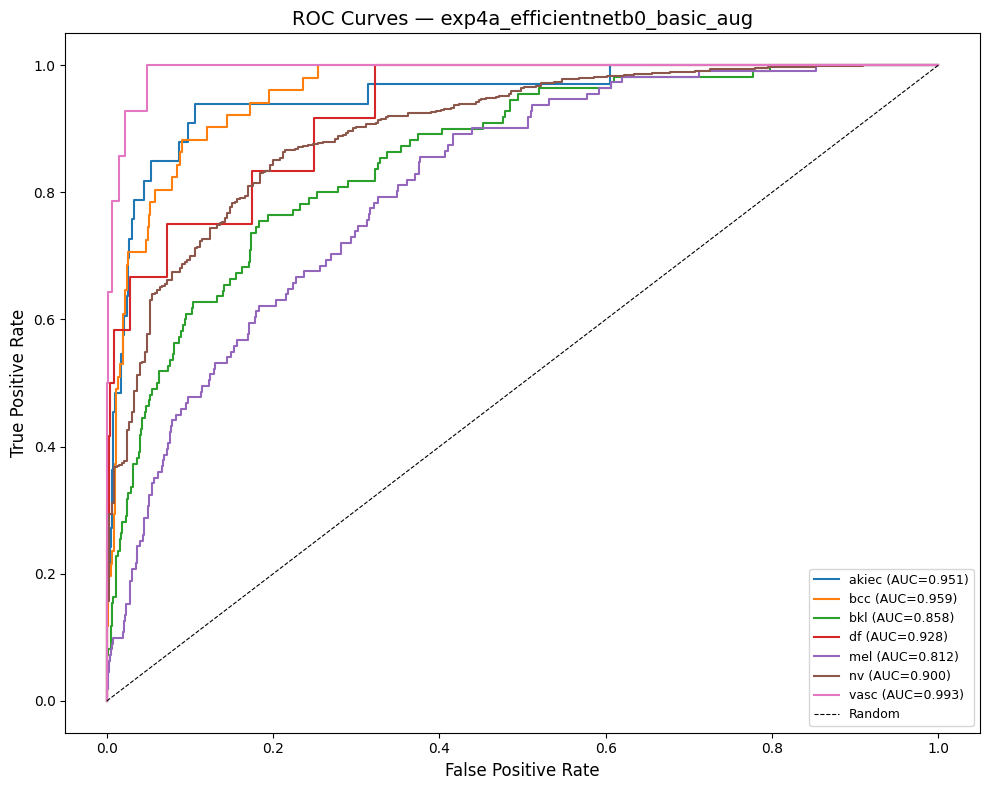


--- KEY METRICS ---
  Overall Accuracy:  0.6128
  Macro F1-Score:    0.5113
  Macro Recall:      0.6128
  Mean AUC-ROC:      0.9145
  Melanoma Recall:   0.5135  ← CRITICAL
  Melanoma F1:       0.3945

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp4a_efficientnetb0_basic_aug_*


epoch/accuracy,▁▄▄▅▅▅▅▆▆▆▆▇▇▇▇▄▄▃▃▄▄▄▅▅▅▆▆▆▇▇▇▇▇██
epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/learning_rate,██████████████▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁█▅▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▂▆▆▆▆▆▇██▆██▇▇▇▂▂▁▁▂▁▂▂▃▃▄▄▄▅▅▆▆▆▆▆
epoch/val_loss,▅▃▃▂▂▂▂▁▁▂▁▁▂▂▂████▇▇▆▆▆▅▅▄▄▄▃▃▃▃▃▃
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp4a_efficientnetb0_basic_aug COMPLETE



In [5]:
model_effnet_basic, summary_effnet_basic = run_experiment(
    experiment_name="exp4a_efficientnetb0_basic_aug",
    train_ds=train_ds_basic,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_efficientnetb0,
    class_weights=class_weights,
    use_class_weights=True,
    architecture_name="EfficientNet-B0"
)


############################################################
  EXPERIMENT: exp4b_efficientnetb0_mixup_cutmix
############################################################



EfficientNet-B0 built. Base layers: 238, Total params: 4,379,306

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 61s 228ms/step - accuracy: 0.6769 - loss: 1.0029 - val_accuracy: 0.6863 - val_loss: 0.8053 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 224ms/step - accuracy: 0.6985 - loss: 0.9051 - val_accuracy: 0.7043 - val_loss: 0.7675 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 223ms/step - accuracy: 0.7086 - loss: 0.8816 - val_accuracy: 0.7283 - val_loss: 0.7153 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 225ms/step - accuracy: 0.7147 - loss: 0.8652 - val_accuracy: 0.7343 - val_loss: 0.6743 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 222ms/step - accuracy: 0.7112 - loss: 0.8607 - val_accuracy: 0.7293 - val_loss: 0.6846 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 222ms/step - accuracy: 0.7232 - loss: 0.8519 - val_accuracy: 0.74

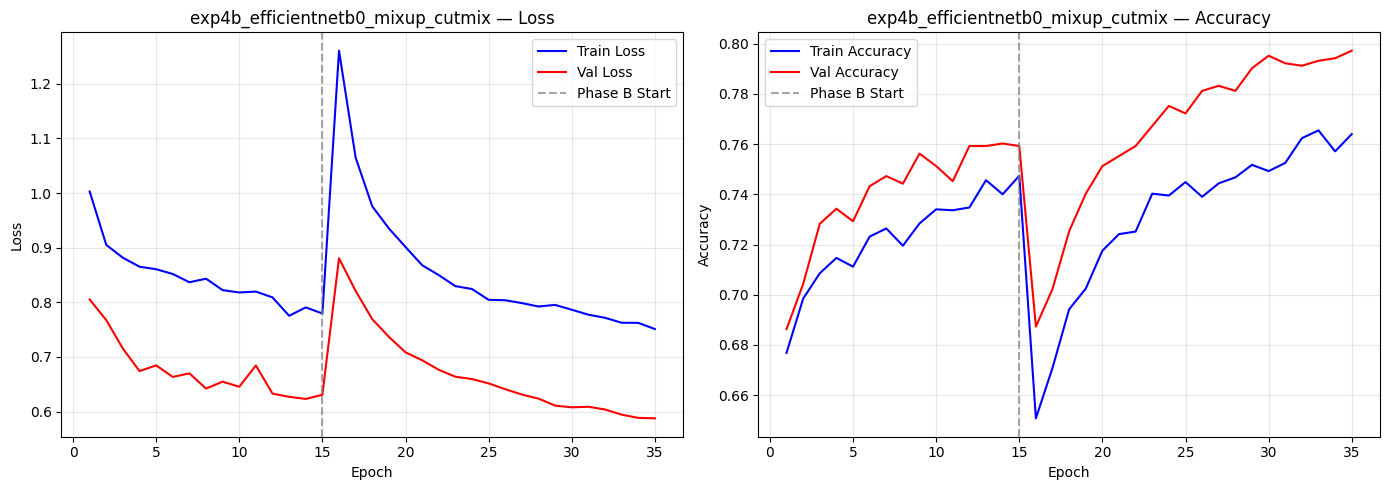


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp4b_efficientnetb0_mixup_cutmix_final.keras

  EVALUATION: exp4b_efficientnetb0_mixup_cutmix

              precision    recall  f1-score   support

       akiec     0.7778    0.2121    0.3333        33
         bcc     0.7143    0.4902    0.5814        51
         bkl     0.4774    0.6727    0.5585       110
          df     1.0000    0.0833    0.1538        12
         mel     0.4853    0.2973    0.3687       111
          nv     0.8603    0.9270    0.8924       671
        vasc     0.8182    0.6429    0.7200        14

    accuracy                         0.7695      1002
   macro avg     0.7333    0.4751    0.5155      1002
weighted avg     0.7677    0.7695    0.7522      1002



2026-03-13 22:35:14.273581: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


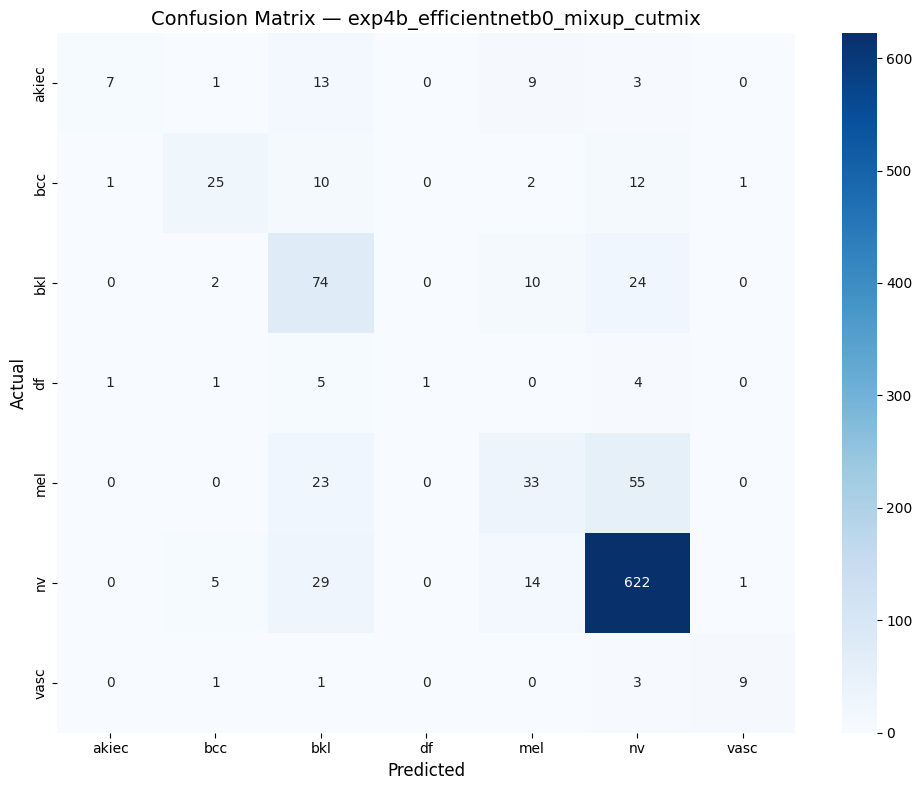

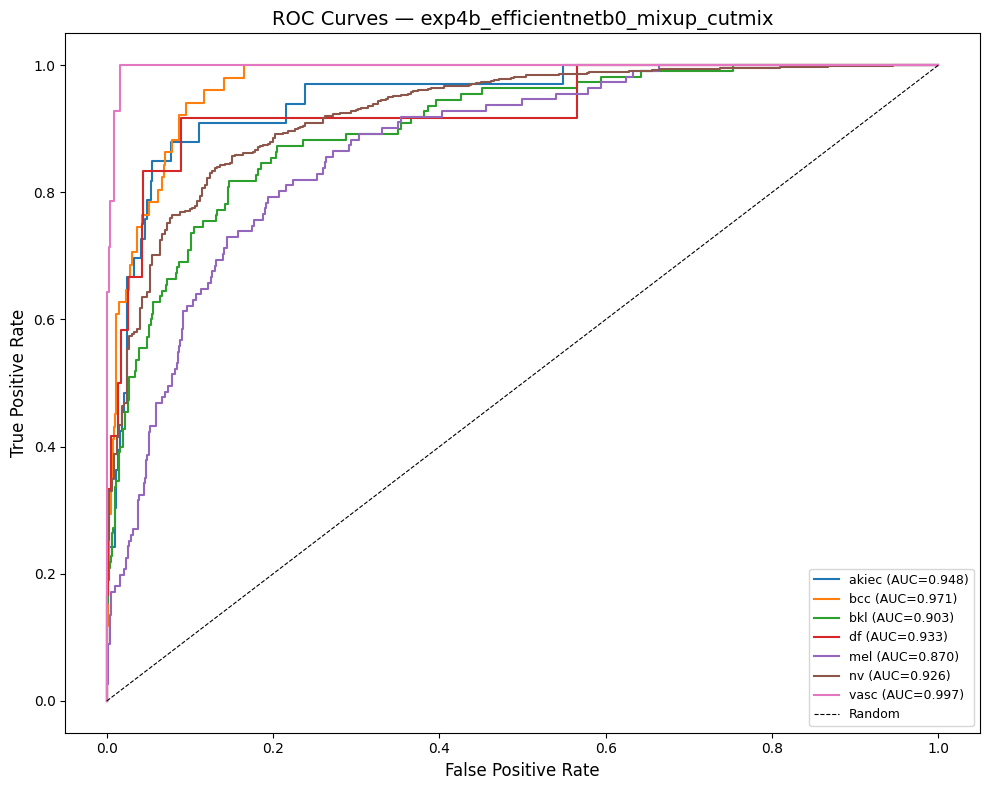


--- KEY METRICS ---
  Overall Accuracy:  0.7695
  Macro F1-Score:    0.5155
  Macro Recall:      0.4751
  Mean AUC-ROC:      0.9354
  Melanoma Recall:   0.2973  ← CRITICAL
  Melanoma F1:       0.3687

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp4b_efficientnetb0_mixup_cutmix_*


epoch/accuracy,▃▄▅▅▅▅▆▅▆▆▆▆▇▆▇▁▂▄▄▅▅▆▆▆▇▆▇▇▇▇▇██▇█
epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/learning_rate,██████████▄▄▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,▄▃▃▃▃▂▂▂▂▂▂▂▁▂▁█▅▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
epoch/val_accuracy,▁▂▄▄▄▅▅▅▅▅▅▆▆▆▆▁▂▃▄▅▅▆▆▇▆▇▇▇███████
epoch/val_loss,▆▅▄▃▃▃▃▂▃▂▃▂▂▂▂█▇▅▅▄▄▃▃▃▃▂▂▂▂▁▂▁▁▁▁
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp4b_efficientnetb0_mixup_cutmix COMPLETE



In [6]:
model_effnet_mixup, summary_effnet_mixup = run_experiment(
    experiment_name="exp4b_efficientnetb0_mixup_cutmix",
    train_ds=train_ds_advanced,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_efficientnetb0,
    class_weights=class_weights,
    use_class_weights=False,
    architecture_name="EfficientNet-B0"
)


############################################################
  EXPERIMENT: exp5a_mobilenetv2_basic_aug
############################################################



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 built. Base layers: 154, Total params: 2,587,719

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 151ms/step - accuracy: 0.4412 - loss: 1.6356 - val_accuracy: 0.4845 - val_loss: 1.2957 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 145ms/step - accuracy: 0.5203 - loss: 1.2684 - val_accuracy: 0.6394 - val_loss: 0.9451 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 142ms/step - accuracy: 0.5518 - loss: 1.1994 - val_accuracy: 0.5744 - val_loss: 1.0909 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.5699 - loss: 1.1192 - val_accuracy: 0.6174 - val_loss: 0.9813 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5924 - loss: 1.0650
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy:

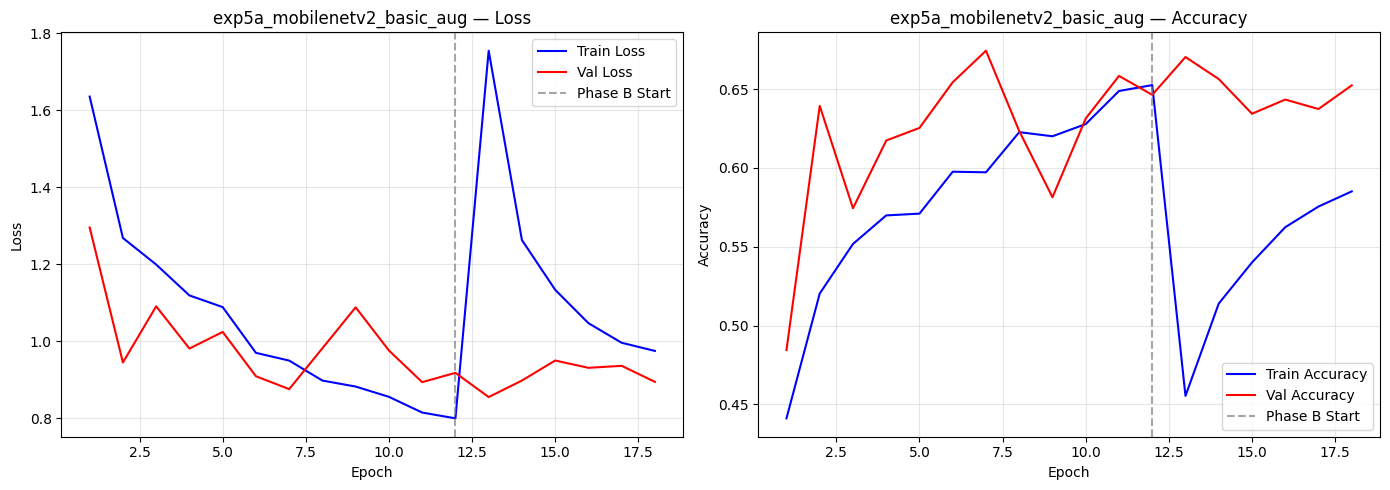


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp5a_mobilenetv2_basic_aug_final.keras

  EVALUATION: exp5a_mobilenetv2_basic_aug

              precision    recall  f1-score   support

       akiec     0.3871    0.3636    0.3750        33
         bcc     0.6087    0.5490    0.5773        51
         bkl     0.3667    0.5000    0.4231       110
          df     0.1053    0.6667    0.1818        12
         mel     0.3485    0.4144    0.3786       111
          nv     0.9164    0.7347    0.8156       671
        vasc     0.3448    0.7143    0.4651        14

    accuracy                         0.6507      1002
   macro avg     0.4396    0.5632    0.4595      1002
weighted avg     0.7423    0.6507    0.6849      1002



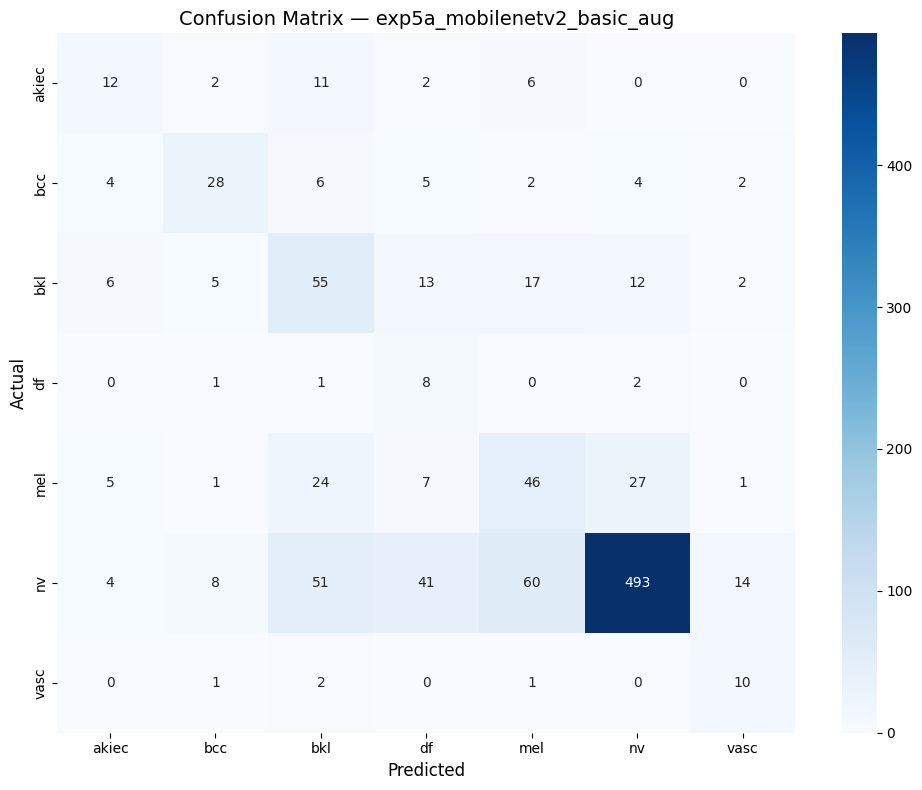

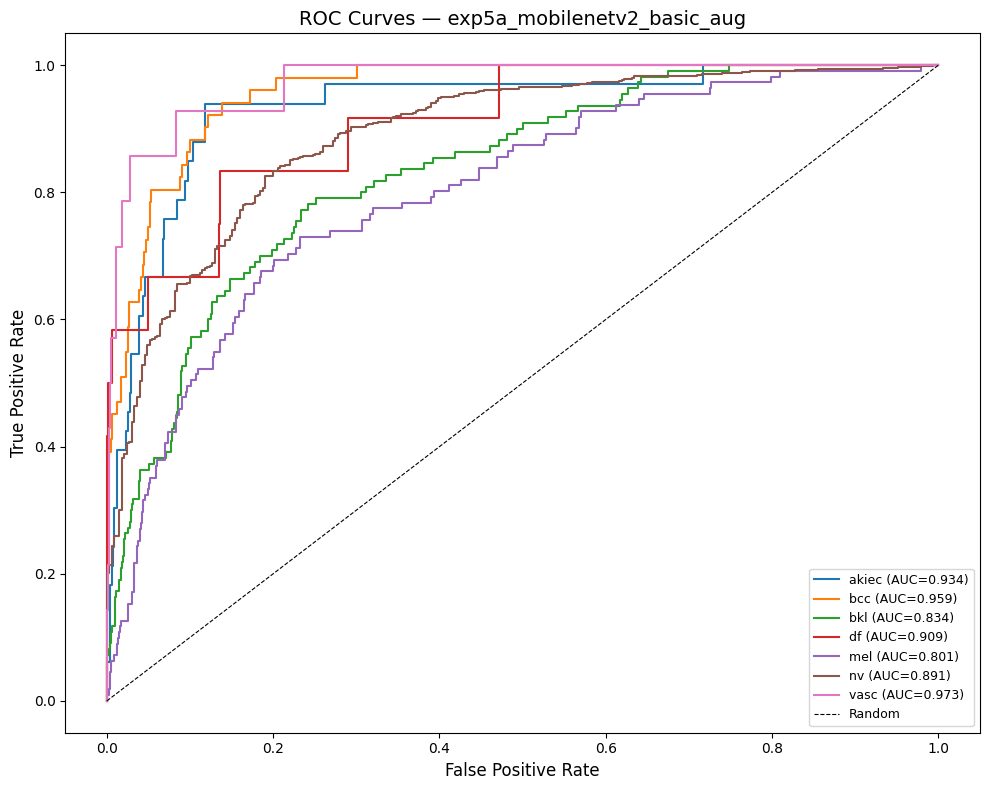


--- KEY METRICS ---
  Overall Accuracy:  0.6507
  Macro F1-Score:    0.4595
  Macro Recall:      0.5632
  Mean AUC-ROC:      0.9000
  Melanoma Recall:   0.4144  ← CRITICAL
  Melanoma F1:       0.3786

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp5a_mobilenetv2_basic_aug_*


epoch/accuracy,▁▄▅▅▅▆▆▇▇▇██▁▃▄▅▅▆
epoch/epoch,▁▂▂▃▄▄▅▅▆▇▇█▁▂▂▃▄▄
epoch/learning_rate,████▄▄▄▄▄▃▃▃▁▁▁▁▁▁
epoch/loss,▇▄▄▃▃▂▂▂▂▁▁▁█▄▃▃▂▂
epoch/val_accuracy,▁▇▄▆▆▇█▆▅▆▇▇█▇▇▇▇▇
epoch/val_loss,█▂▅▃▄▂▁▃▅▃▂▂▁▂▃▂▂▂
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp5a_mobilenetv2_basic_aug COMPLETE



In [7]:
 model_mobile_basic, summary_mobile_basic = run_experiment(
    experiment_name="exp5a_mobilenetv2_basic_aug",
    train_ds=train_ds_basic,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_mobilenetv2,
    class_weights=class_weights,
    use_class_weights=True,
    architecture_name="MobileNetV2"
)


############################################################
  EXPERIMENT: exp5b_mobilenetv2_mixup_cutmix
############################################################



MobileNetV2 built. Base layers: 154, Total params: 2,587,719

--- PHASE A: Feature Extraction (Frozen Base) ---
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 155ms/step - accuracy: 0.6820 - loss: 1.0237 - val_accuracy: 0.6933 - val_loss: 0.7971 - learning_rate: 0.0010
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 151ms/step - accuracy: 0.7014 - loss: 0.9265 - val_accuracy: 0.7123 - val_loss: 0.7556 - learning_rate: 0.0010
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 152ms/step - accuracy: 0.7008 - loss: 0.9035 - val_accuracy: 0.7363 - val_loss: 0.7596 - learning_rate: 0.0010
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 149ms/step - accuracy: 0.7054 - loss: 0.8998 - val_accuracy: 0.7163 - val_loss: 0.7406 - learning_rate: 0.0010
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - accuracy: 0.7118 - loss: 0.8744 - val_accuracy: 0.7353 - val_loss: 0.7152 - learning_rate: 0.0010
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 148ms/step - accuracy: 0.7209 - loss: 0.8671 - val_accuracy: 0.7453 -

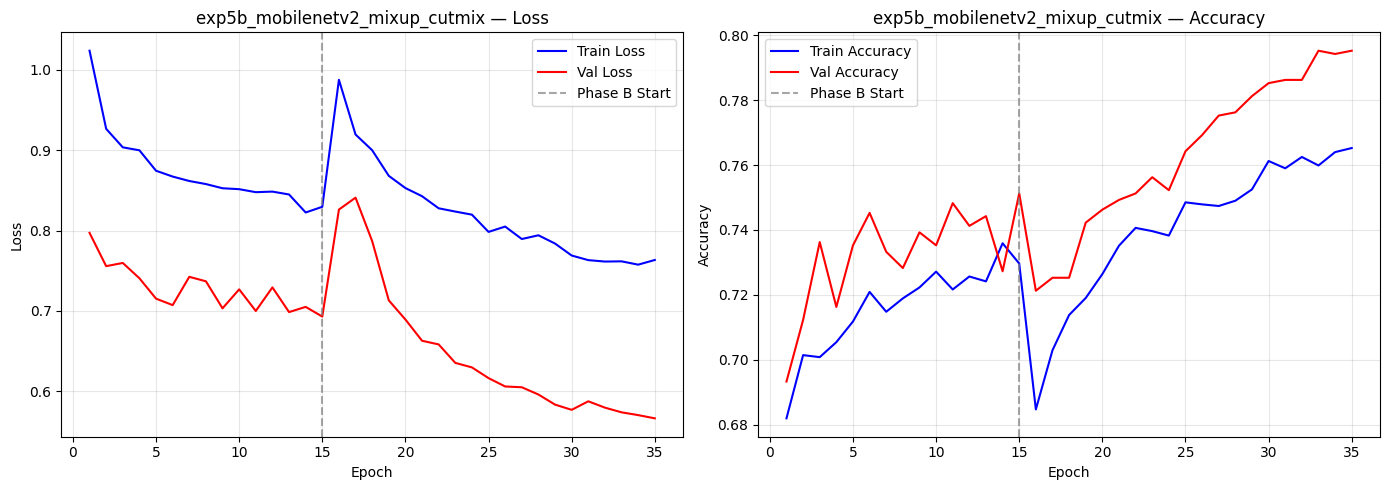


Model saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/models/exp5b_mobilenetv2_mixup_cutmix_final.keras

  EVALUATION: exp5b_mobilenetv2_mixup_cutmix

              precision    recall  f1-score   support

       akiec     0.5000    0.1515    0.2326        33
         bcc     0.6486    0.4706    0.5455        51
         bkl     0.5682    0.6818    0.6198       110
          df     0.5000    0.0833    0.1429        12
         mel     0.4933    0.3333    0.3978       111
          nv     0.8612    0.9434    0.9004       671
        vasc     0.8182    0.6429    0.7200        14

    accuracy                         0.7824      1002
   macro avg     0.6271    0.4724    0.5084      1002
weighted avg     0.7607    0.7824    0.7623      1002



2026-03-13 23:56:27.199201: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


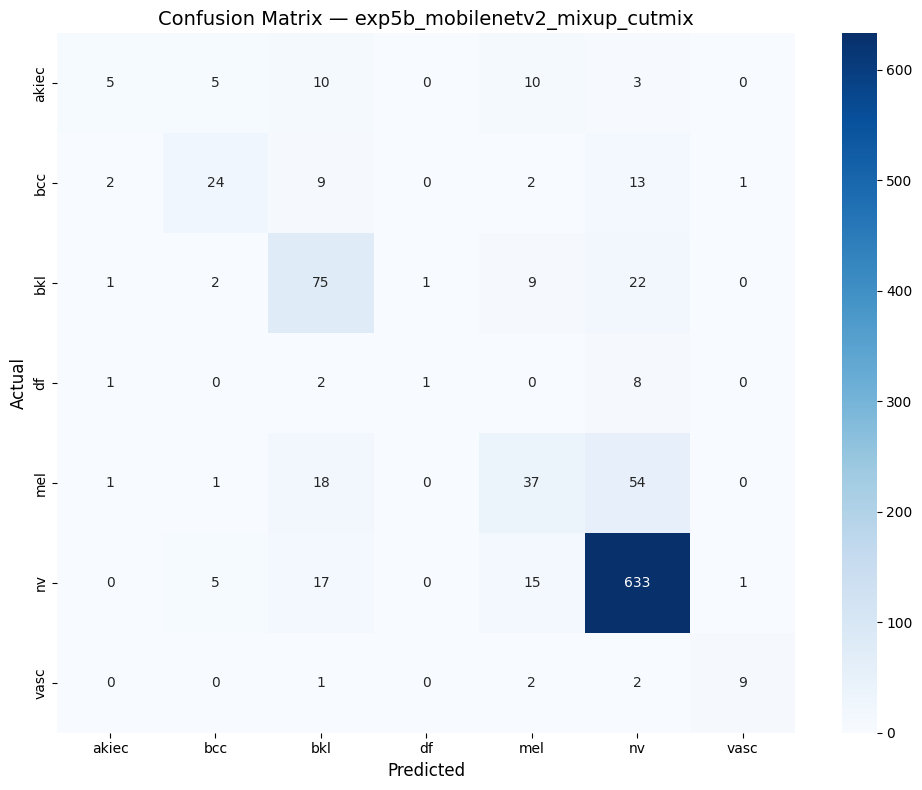

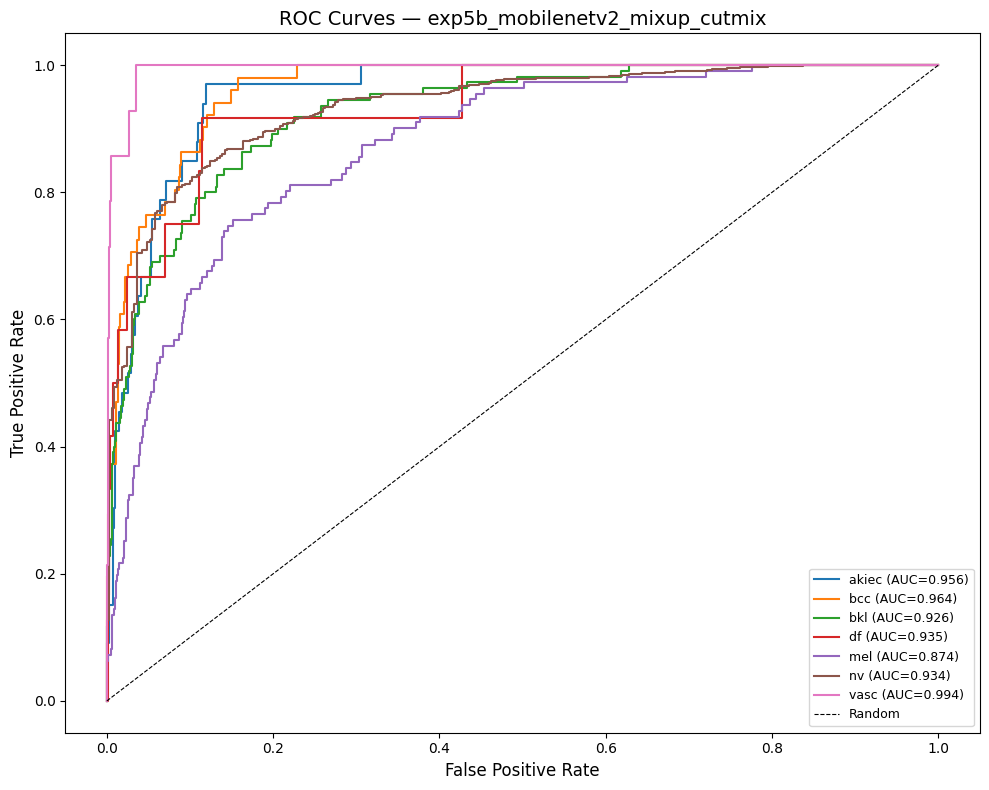


--- KEY METRICS ---
  Overall Accuracy:  0.7824
  Macro F1-Score:    0.5084
  Macro Recall:      0.4724
  Mean AUC-ROC:      0.9404
  Melanoma Recall:   0.3333  ← CRITICAL
  Melanoma F1:       0.3978

  Results saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/exp5b_mobilenetv2_mixup_cutmix_*


epoch/accuracy,▁▃▃▃▄▄▄▄▄▅▄▅▅▆▅▁▃▄▄▅▅▆▆▆▇▇▆▇▇█▇████
epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/learning_rate,███████████████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▅▅▄▄▄▄▃▃▃▃▃▃▃▇▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
epoch/val_accuracy,▁▂▄▃▄▅▄▃▄▄▅▄▄▃▅▃▃▃▄▅▅▅▅▅▆▆▇▇▇▇▇▇███
epoch/val_loss,▇▆▆▅▅▅▅▅▄▅▄▅▄▅▄██▇▅▄▃▃▃▃▂▂▂▂▁▁▂▁▁▁▁
test/accuracy,▁
test/macro_f1,▁
test/macro_recall,▁
test/mean_auc,▁
+2,...



  exp5b_mobilenetv2_mixup_cutmix COMPLETE



In [8]:
model_mobile_mixup, summary_mobile_mixup = run_experiment(
    experiment_name="exp5b_mobilenetv2_mixup_cutmix",
    train_ds=train_ds_advanced,
    val_ds=val_ds,
    test_ds=test_ds,
    build_model_fn=build_mobilenetv2,
    class_weights=class_weights,
    use_class_weights=False,
    architecture_name="MobileNetV2"
)


  stage2 RESULTS COMPARISON
                       Experiment Accuracy Macro F1 Macro Recall Mean AUC Mel Recall Mel F1
          exp1_resnet50_basic_aug   0.7715   0.6887       0.7397   0.9545     0.8018 0.5914
       exp2_resnet50_mixup_cutmix   0.8313   0.6937       0.6465   0.9635     0.4775 0.5521
   exp4a_efficientnetb0_basic_aug   0.6128   0.5113       0.6128   0.9145     0.5135 0.3945
exp4b_efficientnetb0_mixup_cutmix   0.7695   0.5155       0.4751   0.9354     0.2973 0.3687
      exp5a_mobilenetv2_basic_aug   0.6507   0.4595       0.5632   0.9000     0.4144 0.3786
   exp5b_mobilenetv2_mixup_cutmix   0.7824   0.5084       0.4724   0.9404     0.3333 0.3978

--- Per-Class F1 Scores ---
       exp1_resnet50_basic_aug  exp2_resnet50_mixup_cutmix  exp4a_efficientnetb0_basic_aug  exp4b_efficientnetb0_mixup_cutmix  exp5a_mobilenetv2_basic_aug  exp5b_mobilenetv2_mixup_cutmix
akiec                 0.677966                    0.629630                        0.500000                     

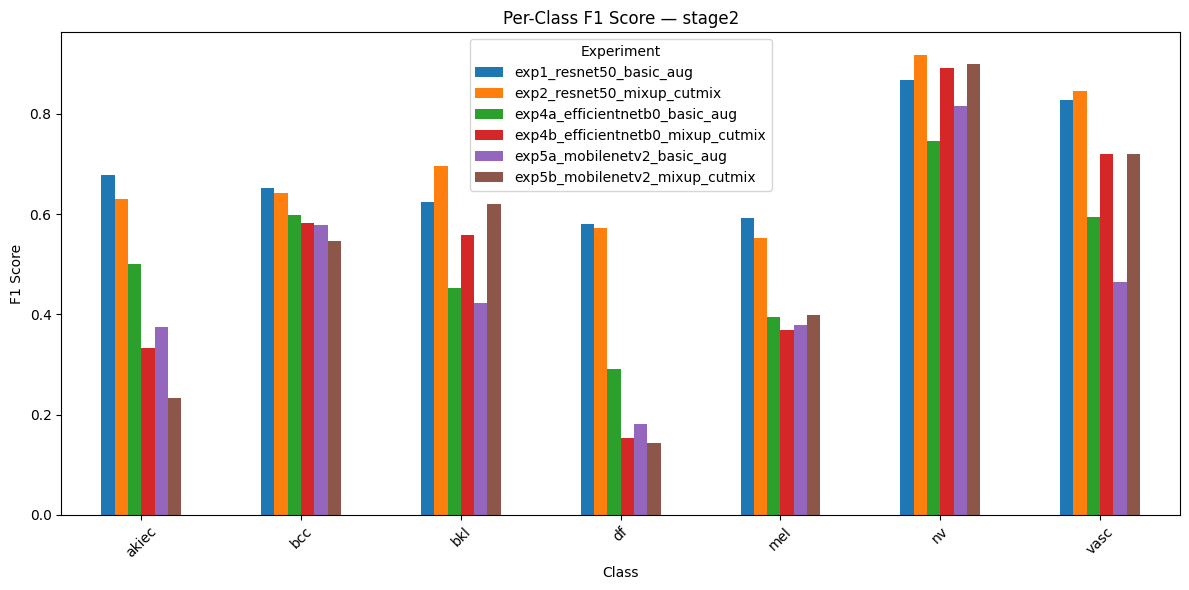


--- Per-Class Recall (Sensitivity) ---
       exp1_resnet50_basic_aug  exp2_resnet50_mixup_cutmix  exp4a_efficientnetb0_basic_aug  exp4b_efficientnetb0_mixup_cutmix  exp5a_mobilenetv2_basic_aug  exp5b_mobilenetv2_mixup_cutmix
akiec                 0.606061                    0.515152                        0.454545                           0.212121                     0.363636                        0.151515
bcc                   0.588235                    0.529412                        0.568627                           0.490196                     0.549020                        0.470588
bkl                   0.790909                    0.772727                        0.772727                           0.672727                     0.500000                        0.681818
df                    0.750000                    0.500000                        0.583333                           0.083333                     0.666667                        0.083333
mel                   0.8

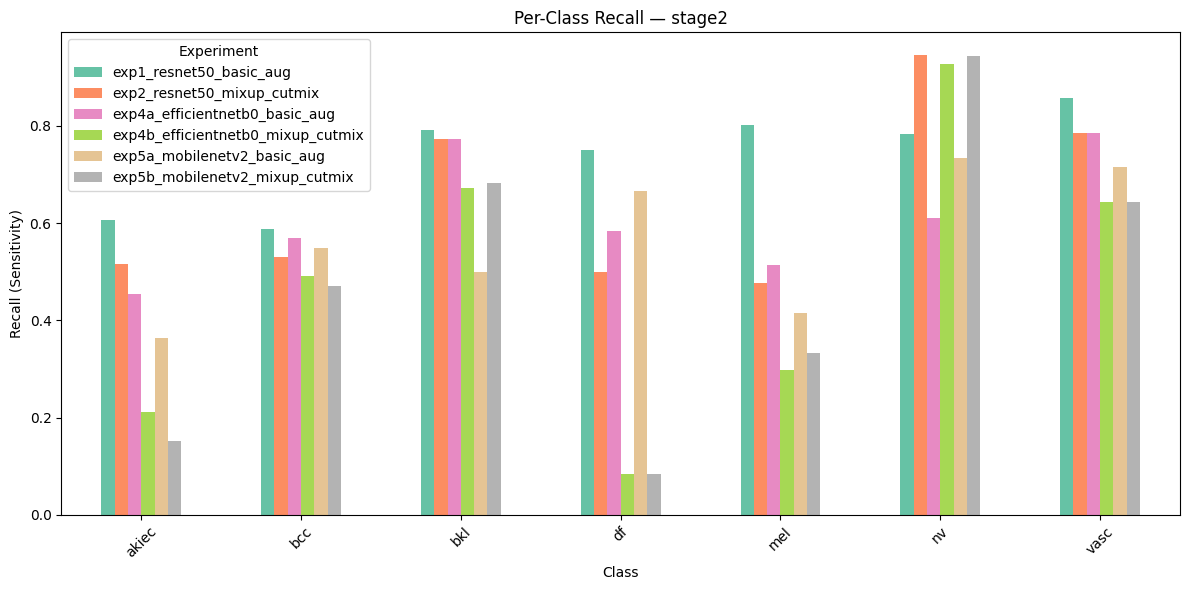

,Experiment,Accuracy,Macro F1,Macro Recall,Mean AUC,Mel Recall,Mel F1
0,exp1_resnet50_basic_aug,0.7715,0.6887,0.7397,0.9545,0.8018,0.5914
1,exp2_resnet50_mixup_cutmix,0.8313,0.6937,0.6465,0.9635,0.4775,0.5521
2,exp4a_efficientnetb0_basic_aug,0.6128,0.5113,0.6128,0.9145,0.5135,0.3945
3,exp4b_efficientnetb0_mixup_cutmix,0.7695,0.5155,0.4751,0.9354,0.2973,0.3687
4,exp5a_mobilenetv2_basic_aug,0.6507,0.4595,0.5632,0.9000,0.4144,0.3786
5,exp5b_mobilenetv2_mixup_cutmix,0.7824,0.5084,0.4724,0.9404,0.3333,0.3978


In [9]:
all_summaries = [
    summary_resnet_basic,
    summary_resnet_mixup,
    summary_effnet_basic,
    summary_effnet_mixup,
    summary_mobile_basic,
    summary_mobile_mixup,
]
 
compare_experiments(all_summaries, "stage2")


  ARCHITECTURE COMPARISON (Traditional Augmentation)

  stage2_basic_aug RESULTS COMPARISON
                    Experiment Accuracy Macro F1 Macro Recall Mean AUC Mel Recall Mel F1
       exp1_resnet50_basic_aug   0.7715   0.6887       0.7397   0.9545     0.8018 0.5914
exp4a_efficientnetb0_basic_aug   0.6128   0.5113       0.6128   0.9145     0.5135 0.3945
   exp5a_mobilenetv2_basic_aug   0.6507   0.4595       0.5632   0.9000     0.4144 0.3786

--- Per-Class F1 Scores ---
       exp1_resnet50_basic_aug  exp4a_efficientnetb0_basic_aug  exp5a_mobilenetv2_basic_aug
akiec                 0.677966                        0.500000                     0.375000
bcc                   0.652174                        0.597938                     0.577320
bkl                   0.623656                        0.453333                     0.423077
df                    0.580645                        0.291667                     0.181818
mel                   0.591362                        0.394464

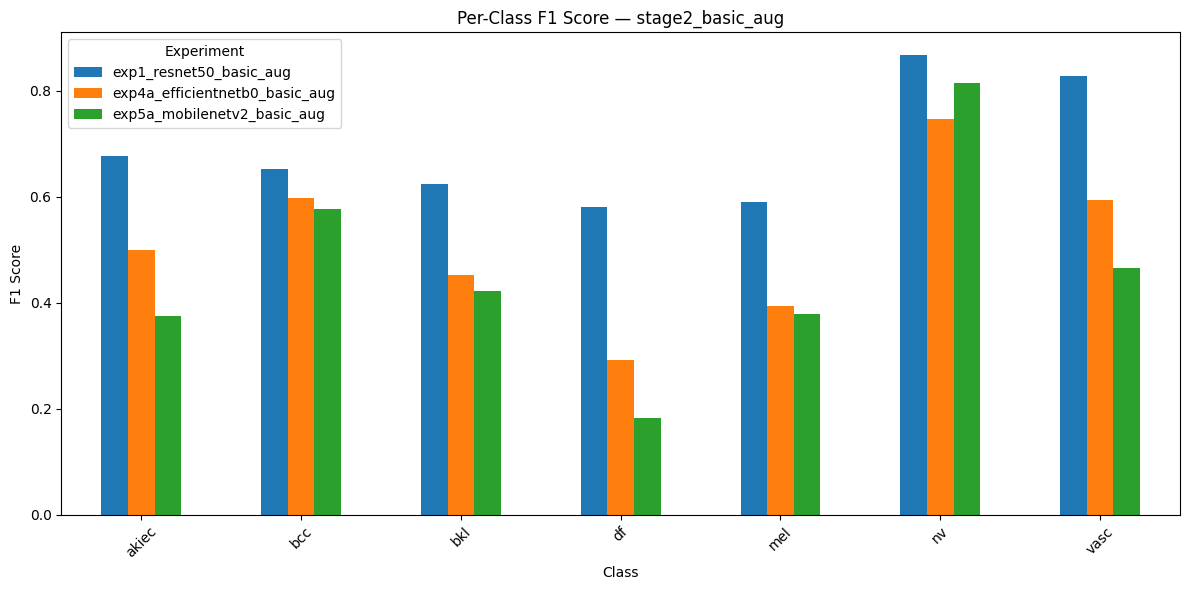


--- Per-Class Recall (Sensitivity) ---
       exp1_resnet50_basic_aug  exp4a_efficientnetb0_basic_aug  exp5a_mobilenetv2_basic_aug
akiec                 0.606061                        0.454545                     0.363636
bcc                   0.588235                        0.568627                     0.549020
bkl                   0.790909                        0.772727                     0.500000
df                    0.750000                        0.583333                     0.666667
mel                   0.801802                        0.513514                     0.414414
nv                    0.783905                        0.611028                     0.734724
vasc                  0.857143                        0.785714                     0.714286


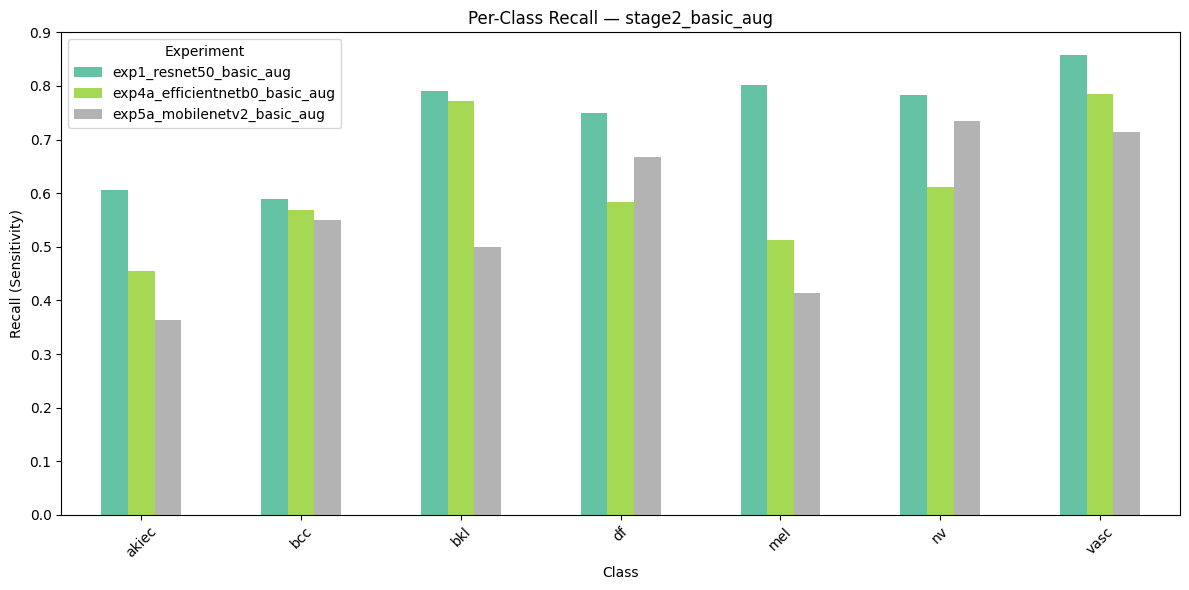

,Experiment,Accuracy,Macro F1,Macro Recall,Mean AUC,Mel Recall,Mel F1
0,exp1_resnet50_basic_aug,0.7715,0.6887,0.7397,0.9545,0.8018,0.5914
1,exp4a_efficientnetb0_basic_aug,0.6128,0.5113,0.6128,0.9145,0.5135,0.3945
2,exp5a_mobilenetv2_basic_aug,0.6507,0.4595,0.5632,0.9000,0.4144,0.3786


In [10]:
#  Comparison by Architecture (Traditional Aug Only)
# =============================================================================
# This isolates the architecture variable with the same augmentation strategy.
 
print("\n" + "=" * 60)
print("  ARCHITECTURE COMPARISON (Traditional Augmentation)")
print("=" * 60)
 
basic_summaries = [summary_resnet_basic, summary_effnet_basic, summary_mobile_basic]
compare_experiments(basic_summaries, "stage2_basic_aug")


  ARCHITECTURE COMPARISON (MixUp/CutMix)

  stage2_mixup_cutmix RESULTS COMPARISON
                       Experiment Accuracy Macro F1 Macro Recall Mean AUC Mel Recall Mel F1
       exp2_resnet50_mixup_cutmix   0.8313   0.6937       0.6465   0.9635     0.4775 0.5521
exp4b_efficientnetb0_mixup_cutmix   0.7695   0.5155       0.4751   0.9354     0.2973 0.3687
   exp5b_mobilenetv2_mixup_cutmix   0.7824   0.5084       0.4724   0.9404     0.3333 0.3978

--- Per-Class F1 Scores ---
       exp2_resnet50_mixup_cutmix  exp4b_efficientnetb0_mixup_cutmix  exp5b_mobilenetv2_mixup_cutmix
akiec                    0.629630                           0.333333                        0.232558
bcc                      0.642857                           0.581395                        0.545455
bkl                      0.696721                           0.558491                        0.619835
df                       0.571429                           0.153846                        0.142857
mel           

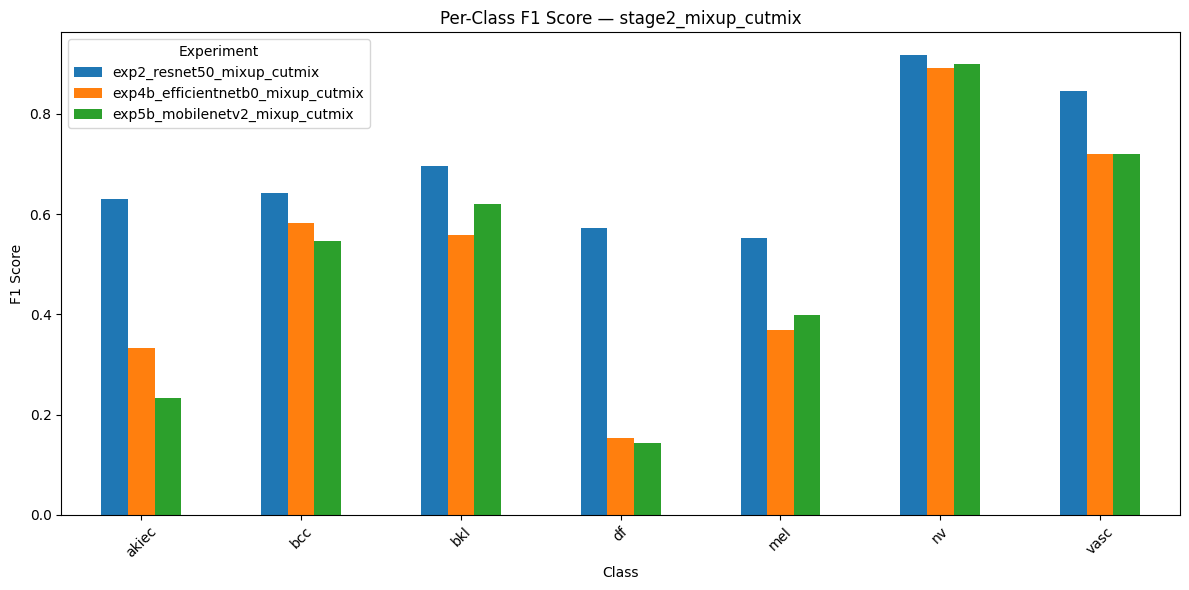


--- Per-Class Recall (Sensitivity) ---
       exp2_resnet50_mixup_cutmix  exp4b_efficientnetb0_mixup_cutmix  exp5b_mobilenetv2_mixup_cutmix
akiec                    0.515152                           0.212121                        0.151515
bcc                      0.529412                           0.490196                        0.470588
bkl                      0.772727                           0.672727                        0.681818
df                       0.500000                           0.083333                        0.083333
mel                      0.477477                           0.297297                        0.333333
nv                       0.944858                           0.926975                        0.943368
vasc                     0.785714                           0.642857                        0.642857


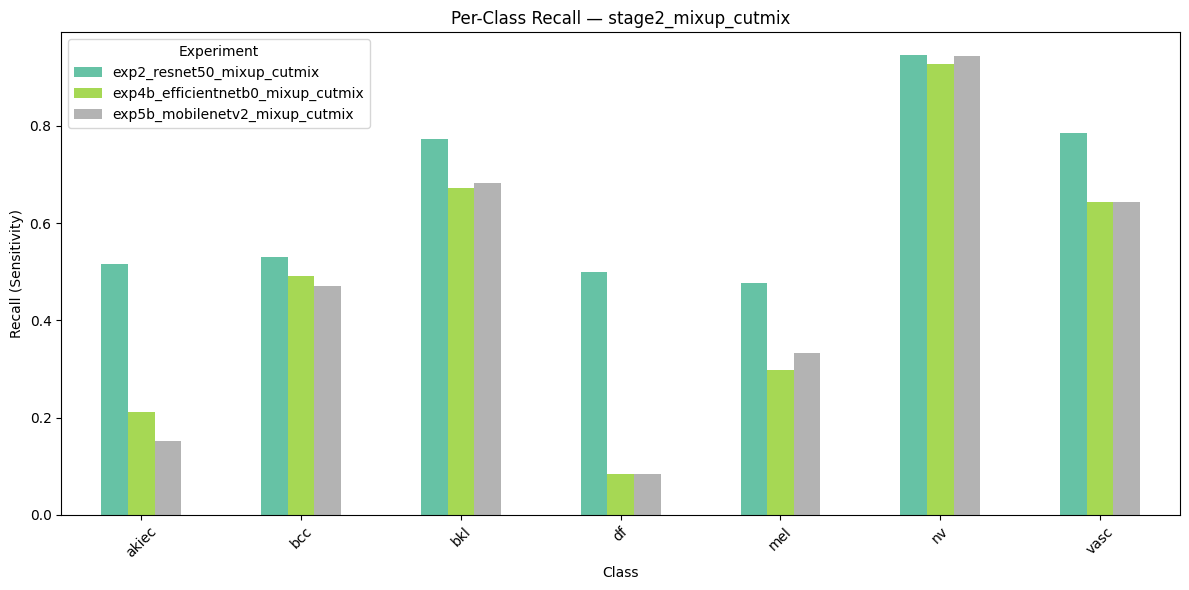

,Experiment,Accuracy,Macro F1,Macro Recall,Mean AUC,Mel Recall,Mel F1
0,exp2_resnet50_mixup_cutmix,0.8313,0.6937,0.6465,0.9635,0.4775,0.5521
1,exp4b_efficientnetb0_mixup_cutmix,0.7695,0.5155,0.4751,0.9354,0.2973,0.3687
2,exp5b_mobilenetv2_mixup_cutmix,0.7824,0.5084,0.4724,0.9404,0.3333,0.3978


In [11]:
# Comparison by Architecture (MixUp/CutMix Only)
# =============================================================================
 
print("\n" + "=" * 60)
print("  ARCHITECTURE COMPARISON (MixUp/CutMix)")
print("=" * 60)
 
mixup_summaries = [summary_resnet_mixup, summary_effnet_mixup, summary_mobile_mixup]
compare_experiments(mixup_summaries, "stage2_mixup_cutmix")

In [13]:
# Select Best Overall Model for Stage 3 (Grad-CAM)
# =============================================================================
# Selected using two criteria and discuss the tradeoff.
 
print("\n" + "=" * 70)
print("  BEST MODEL SELECTION FOR STAGE 3 (GRAD-CAM)")
print("=" * 70)
 
# By Macro F1 (overall balanced performance)
best_f1_idx, best_f1 = select_best_experiment(all_summaries, 'macro_f1')
print(f"\n  Best by Macro F1: {best_f1['experiment']}")
 
# By Melanoma Recall (clinical priority)
best_mel_idx, best_mel = select_best_experiment(all_summaries, 'mel_recall')
print(f"  Best by Mel Recall: {best_mel['experiment']}")
 
# Recommendation
if best_f1_idx == best_mel_idx:
    best_overall = best_f1
    print(f"\n  BOTH criteria agree → {best_overall['experiment']}")
else:
    print(f"\n  CRITERIA DISAGREE:")
    print(f"    Macro F1 winner:  {best_f1['experiment']} (F1={best_f1['macro_f1']:.4f}, MelRec={best_f1['mel_recall']:.4f})")
    print(f"    Mel Recall winner: {best_mel['experiment']} (F1={best_mel['macro_f1']:.4f}, MelRec={best_mel['mel_recall']:.4f})")
    print(f"\n  For a medical project, Melanoma Recall is the priority.")
    print(f"  Recommended for Grad-CAM: {best_mel['experiment']}")
    best_overall = best_mel
 
# Save decision
with open(os.path.join(RESULTS_DIR, "stage2_best_model.json"), 'w') as f:
    json.dump({
        "best_by_macro_f1": best_f1['experiment'],
        "best_by_mel_recall": best_mel['experiment'],
        "selected_for_gradcam": best_overall['experiment'],
        "macro_f1": float(best_overall['macro_f1']),
        "mel_recall": float(best_overall['mel_recall']),
        "mean_auc": float(best_overall['mean_auc']),
    }, f, indent=2)
 
print(f"\n  Decision saved to: {RESULTS_DIR}/stage2_best_model.json")


  BEST MODEL SELECTION FOR STAGE 3 (GRAD-CAM)

  BEST EXPERIMENT (by macro_f1)
  Winner:       exp2_resnet50_mixup_cutmix
  Macro F1:     0.6937
  Mel Recall:   0.4775
  Mean AUC:     0.9635

  Best by Macro F1: exp2_resnet50_mixup_cutmix

  BEST EXPERIMENT (by mel_recall)
  Winner:       exp1_resnet50_basic_aug
  Macro F1:     0.6887
  Mel Recall:   0.8018
  Mean AUC:     0.9545
  Best by Mel Recall: exp1_resnet50_basic_aug

  CRITERIA DISAGREE:
    Macro F1 winner:  exp2_resnet50_mixup_cutmix (F1=0.6937, MelRec=0.4775)
    Mel Recall winner: exp1_resnet50_basic_aug (F1=0.6887, MelRec=0.8018)

  For a medical project, Melanoma Recall is the priority.
  Recommended for Grad-CAM: exp1_resnet50_basic_aug

  Decision saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/stage2_best_model.json


In [14]:
# Summary Table for Report
# =============================================================================

print("\n" + "=" * 70)
print("  TABLE FOR FINAL REPORT")
print("=" * 70)
 
report_data = []
for s in all_summaries:
    name = s['experiment']
    # Extract architecture and strategy from experiment name
    if 'resnet' in name:
        arch = 'ResNet50'
    elif 'efficientnet' in name:
        arch = 'EfficientNet-B0'
    else:
        arch = 'MobileNetV2'
    
    strategy = 'MixUp/CutMix' if 'mixup' in name else 'Traditional Aug'
    
    report_data.append({
        'Architecture': arch,
        'Augmentation': strategy,
        'Accuracy': f"{s['accuracy']:.4f}",
        'Macro F1': f"{s['macro_f1']:.4f}",
        'Mel Recall': f"{s['mel_recall']:.4f}",
        'Mel F1': f"{s['mel_f1']:.4f}",
        'Mean AUC': f"{s['mean_auc']:.4f}",
    })
 
report_df = pd.DataFrame(report_data)
print(report_df.to_string(index=False))
report_df.to_csv(os.path.join(RESULTS_DIR, "stage2_report_table.csv"), index=False)
print(f"\nSaved to: {RESULTS_DIR}/stage2_report_table.csv")


  TABLE FOR FINAL REPORT
   Architecture    Augmentation Accuracy Macro F1 Mel Recall Mel F1 Mean AUC
       ResNet50 Traditional Aug   0.7715   0.6887     0.8018 0.5914   0.9545
       ResNet50    MixUp/CutMix   0.8313   0.6937     0.4775 0.5521   0.9635
EfficientNet-B0 Traditional Aug   0.6128   0.5113     0.5135 0.3945   0.9145
EfficientNet-B0    MixUp/CutMix   0.7695   0.5155     0.2973 0.3687   0.9354
    MobileNetV2 Traditional Aug   0.6507   0.4595     0.4144 0.3786   0.9000
    MobileNetV2    MixUp/CutMix   0.7824   0.5084     0.3333 0.3978   0.9404

Saved to: /Users/emiryscn/repos/multi-class-skin-lesion-detection/results/stage2_report_table.csv
